# Efficient data pipelines for video & streaming data

Once the GPUs are fast and many (notebook 03), the bottleneck moves to **feeding them**. This is
especially true for **video**: clips are large, decoding is expensive, and the datasets are far too big
to fit in RAM (or even on local disk) — so you **stream**.

The mental shift from single-GPU toy training:

- The GPU is a hungry, expensive resource. If the input pipeline can't keep up, the GPU **starves** —
  you pay for an A100 and it sits 80% idle.
- You can't preload the dataset. You **stream shards** from object storage, decoding on the fly.
- With many workers *and* many GPUs, every (rank, worker) must read a **disjoint** slice — or you waste
  compute on duplicates.

We'll measure each of these with a synthetic "video clip" source whose per-clip cost stands in for
real decode/resize work.

In [1]:
import time, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, IterableDataset, DataLoader, get_worker_info
import matplotlib.pyplot as plt

DEV = "cuda" if torch.cuda.is_available() else "cpu"
T, H, W = 8, 64, 64          # a clip: 8 frames of 64x64 RGB
DECODE_MS = 4                # simulated per-clip decode/resize cost — video is decode-heavy

def fake_decode(seed):
    # stand-in for "fetch + decode + resize a video clip": a bit of REAL CPU work
    rng = np.random.default_rng(seed)
    x = rng.random((3, T, H, W), dtype=np.float32)
    t0 = time.time()
    while (time.time()-t0) < DECODE_MS/1000.0:
        x = x * 1.0000001
    return torch.from_numpy(x)

class ClipDataset(Dataset):                       # map-style: knows its length, random access
    def __init__(self, n): self.n = n
    def __len__(self): return self.n
    def __getitem__(self, i): return fake_decode(i), i % 10
print("device:", DEV)

device: cuda


## 1. `num_workers`: parallelize the decode

`num_workers=0` decodes clips **in the training process**, serially, between GPU steps. Each extra
worker is a subprocess decoding ahead into a queue. For a decode-bound source this scales almost
linearly — until you saturate CPU cores.

  num_workers=0: 236 clips/s
  num_workers=2: 454 clips/s
  num_workers=4: 890 clips/s
  num_workers=8: 1692 clips/s


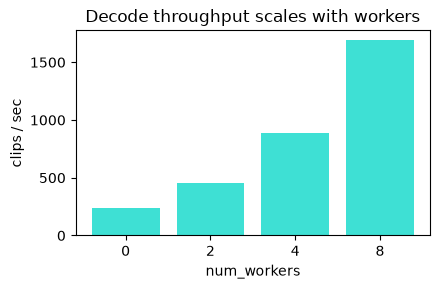

In [2]:
def throughput(num_workers, n=2000, bs=64):
    dl = DataLoader(ClipDataset(n), batch_size=bs, num_workers=num_workers,
                    **(dict(prefetch_factor=2) if num_workers else {}))
    t0=time.time(); seen=0
    for x,_ in dl: seen += x.size(0)
    return seen/(time.time()-t0)

workers = [0,2,4,8]; rates = [throughput(w) for w in workers]
for w,r in zip(workers,rates): print(f"  num_workers={w}: {r:.0f} clips/s")
plt.figure(figsize=(4.5,3)); plt.bar([str(w) for w in workers], rates, color="#3ee0d4")
plt.xlabel("num_workers"); plt.ylabel("clips / sec"); plt.title("Decode throughput scales with workers")
plt.tight_layout(); plt.show()

## 2. Pinned memory: faster host→device transfers

CUDA can only DMA from **page-locked (pinned)** host memory at full speed; pageable memory needs an
extra staging copy. `pin_memory=True` in the DataLoader (plus `.to(device, non_blocking=True)`) lets
transfers run at higher bandwidth **and** overlap with compute on a separate stream.

In [3]:
if DEV=="cuda":
    batch = torch.randn(64, 3*T, H, W)   # ~25 MB, a typical clip batch
    def bw(t):
        torch.cuda.synchronize(); t0=time.time()
        for _ in range(200): t.to(DEV, non_blocking=t.is_pinned()); torch.cuda.synchronize()
        return 200*t.numel()*4/1e9 / (time.time()-t0)
    print(f"  pageable host memory: {bw(batch):.1f} GB/s")
    print(f"  pinned host memory:   {bw(batch.pin_memory()):.1f} GB/s")
else:
    print("(CUDA not available — pinned memory only matters for host->device DMA)")

  pageable host memory: 19.2 GB/s


  pinned host memory:   24.4 GB/s


## 3. Streaming + sharding: the part that's easy to get wrong

Petabyte-scale video doesn't fit anywhere, so you stream **shards** (e.g. `.tar` files of clips, the
WebDataset format) from object storage. A map-style `Dataset` needs random access and a known length;
a streaming **`IterableDataset`** just yields samples.

The trap: with `num_workers > 1` *and* multiple DDP ranks, **every (rank, worker) pair must read a
disjoint slice**, or you train on duplicates. The correct stride is `world_size × num_workers`:

In [4]:
class StreamingClips(IterableDataset):
    def __init__(self, n, world=1, rank=0): self.n=n; self.world=world; self.rank=rank
    def __iter__(self):
        wi = get_worker_info(); nw = wi.num_workers if wi else 1; wid = wi.id if wi else 0
        shard  = self.rank*nw + wid      # this (rank,worker)'s global shard id
        stride = self.world*nw           # total number of shards
        for i in range(shard, self.n, stride):   # disjoint, covers everything exactly once
            yield fake_decode(i), i

def count(world, nw):
    seen=[]
    for r in range(world):
        for _,idx in DataLoader(StreamingClips(600, world=world, rank=r), batch_size=50, num_workers=nw):
            seen += idx.tolist()
    return len(seen), len(set(seen))

tot,uniq = count(world=2, nw=3)
print(f"  2 ranks x 3 workers over 600 clips: emitted {tot}, unique {uniq}  "
      f"-> {'no duplicates, no misses' if tot==uniq==600 else 'SHARDING BUG!'}")
print("  (drop the rank/worker stride and you'd silently train on 6x duplicated data)")

  2 ranks x 3 workers over 600 clips: emitted 600, unique 600  -> no duplicates, no misses
  (drop the rank/worker stride and you'd silently train on 6x duplicated data)


## 4. GPU starvation, measured

Here's why all of the above matters. We run a non-trivial GPU model as the *consumer* and time how much
of the wall clock it spends **stalled waiting for data** vs. actually computing — first with a serial
pipeline, then with enough workers to keep it fed.

In [5]:
if DEV=="cuda":
    enc = nn.Sequential(*([nn.Conv2d(3*T,384,3,1,1), nn.GELU()] +
                          sum([[nn.Conv2d(384,384,3,1,1), nn.GELU()] for _ in range(6)], []))).to(DEV)
    def run(num_workers, n=1200, bs=64):
        dl=DataLoader(ClipDataset(n), batch_size=bs, num_workers=num_workers, pin_memory=True)
        torch.cuda.synchronize(); t0=time.time(); wait=comp=0.0; prev=time.time()
        for x,_ in dl:
            wait += time.time()-prev
            x=x.reshape(x.size(0),3*T,H,W).to(DEV, non_blocking=True)
            c0=time.time(); enc(x); torch.cuda.synchronize(); comp += time.time()-c0; prev=time.time()
        return time.time()-t0, wait, comp
    for nw in [0,8]:
        dt,wait,comp = run(nw)
        print(f"  num_workers={nw}: total {dt:.1f}s | GPU compute {comp:.1f}s | "
              f"stalled for data {wait:.1f}s  ({100*wait/dt:.0f}% GPU idle)")
else:
    print("(needs CUDA to show GPU idle time)")

  num_workers=0: total 6.5s | GPU compute 1.4s | stalled for data 5.1s  (78% GPU idle)


  num_workers=8: total 1.7s | GPU compute 1.3s | stalled for data 0.4s  (22% GPU idle)


## 5. Video-specific concerns & overlap

- **Decoding dominates.** Reading an MP4 and decoding 8–16 frames is far more expensive than the forward
  pass for a small model. Push it onto worker processes (or hardware decoders like NVIDIA DALI / `decord`),
  and sample clips/frames sparsely rather than decoding whole videos.
- **Cache what's stable.** If the encoder is frozen (e.g. DINO-WM, V-JEPA 2 stage 2), **precompute and
  cache the latents once** instead of decoding+encoding every epoch — often a 10–100× pipeline win.
- **Overlap transfer with compute.** Pinned memory + `non_blocking=True` + a one-batch prefetcher lets
  the next batch copy to the GPU while the current one trains (hiding the H2D latency we measured in §2).
- **Shard for the cluster.** Size shards so each worker streams sequentially from object storage
  (`.tar`/WebDataset), shuffle with a bounded buffer (you can't global-shuffle a stream), and shard by
  `world_size × num_workers` (§3) so no rank/worker overlaps.

## 6. What we learned

- **At scale, the input pipeline is a first-class system**, not an afterthought. A fast model on a starved
  pipeline (§4: up to ~80% idle) wastes most of the hardware you paid for.
- **`num_workers`, `pin_memory`, `prefetch`, and overlap** are the cheap, high-leverage knobs — we saw
  workers give near-linear decode throughput and pinned memory raise H2D bandwidth.
- **Streaming + correct sharding** is mandatory once data exceeds disk/RAM and you have multiple ranks;
  the `world_size × num_workers` stride is the one formula to remember.
- **It connects back to notebook 03:** each DDP rank needs its *own* fast, disjoint pipeline. Distributed
  compute and distributed data are the same problem viewed from two ends — and the goal of both is simply
  to keep every expensive GPU busy.